<a href="https://colab.research.google.com/github/mipaillafil/Proyecto_Aeropuertos_Cortes_Marchesse_Paillafil/blob/main/Evaluaci%C3%B3n_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Importación de Librerías

En esta sección, importamos todas las librerías necesarias para el análisis de datos y la construcción de modelos de Machine Learning. Esto incluye bibliotecas para manipulación de datos (`pandas`, `numpy`), visualización (`matplotlib`, `seaborn`), preprocesamiento (`sklearn.preprocessing`, `sklearn.model_selection`), y algoritmos de clasificación (`sklearn.linear_model`, `sklearn.tree`, `sklearn.ensemble`, `sklearn.svm`), así como métricas de evaluación (`sklearn.metrics`).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

## 2. Carga y Visión General del Dataset

Aquí cargamos el dataset `operaciones_aeropuertos_clean.csv` directamente desde un repositorio de GitHub utilizando `pandas`. Una vez cargado, mostramos las primeras filas del DataFrame para tener una vista preliminar de la estructura y el contenido de los datos con los que trabajaremos.

In [ ]:
#Se carga el dataset que se limpio la evaluación anterior
url = "https://raw.githubusercontent.com/mipaillafil/Proyecto_Aeropuertos_Cortes_Marchesse_Paillafil/main/data/operaciones_aeropuertos_clean.csv"
df = pd.read_csv(url)
display(df.head())

,cnt_operaciones,total_operaciones,mes_id_200001.0,mes_id_200002.0,mes_id_200003.0,mes_id_200004.0,mes_id_200005.0,mes_id_200006.0,mes_id_200007.0,mes_id_200008.0,...,aeropuerto_oaci_SCVD,aeropuerto_oaci_SCVH,aeropuerto_oaci_SCVI,aeropuerto_oaci_SCVL,aeropuerto_oaci_SCVM,aeropuerto_oaci_SCVV,aeropuerto_oaci_nan,internacional_domestico_D,internacional_domestico_I,internacional_domestico_nan
0,-0.555716,-0.555716,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.029270,0.029270,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,-0.442135,-0.442135,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,-0.234614,-0.234614,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,-0.490812,-0.490812,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## 3. Exploración general

Realizamos una exploración inicial del dataset para comprender su estructura, tipos de datos y la presencia de valores nulos. Utilizamos `df.info()` para obtener un resumen conciso y `df.columns` para listar todas las características (columnas) presentes en el conjunto de datos.

In [ ]:
# Mostramos la informacion general del dataset
print("Informacion general:")
df.info()

# Mostramos los nombres de columnas
print("Columnas del dataset:")
print(df.columns)

Informacion general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14398 entries, 0 to 14397
Columns: 387 entries, cnt_operaciones to internacional_domestico_nan
dtypes: float64(387)
memory usage: 42.5 MB
Columnas del dataset:
Index(['cnt_operaciones', 'total_operaciones', 'mes_id_200001.0',
       'mes_id_200002.0', 'mes_id_200003.0', 'mes_id_200004.0',
       'mes_id_200005.0', 'mes_id_200006.0', 'mes_id_200007.0',
       'mes_id_200008.0',
       ...
       'aeropuerto_oaci_SCVD', 'aeropuerto_oaci_SCVH', 'aeropuerto_oaci_SCVI',
       'aeropuerto_oaci_SCVL', 'aeropuerto_oaci_SCVM', 'aeropuerto_oaci_SCVV',
       'aeropuerto_oaci_nan', 'internacional_domestico_D',
       'internacional_domestico_I', 'internacional_domestico_nan'],
      dtype='object', length=387)


## 4. Definición de variables

En este paso crucial, definimos claramente la variable objetivo (`y`) que deseamos predecir, que es `'internacional_domestico_D'` (indicando si una operación aérea es doméstica). También identificamos y separamos las variables predictoras (`X`), excluyendo la variable objetivo y su contraparte dummy (`'internacional_domestico_I'`) para evitar multicolinealidad. Finalmente, verificamos las dimensiones de `X` e `y` y mostramos sus primeras filas.

In [ ]:
# Variable objetivo
# Se desea predecir si una operacion aerea corresponde a un vuelo domestico o no
target = "internacional_domestico_D"

# Variables predictoras (X)
# Se eliminan la variable objetivo y la otra variable dummy relacionada porque ambas contienen la misma informacion categorica
X = df.drop([
    "internacional_domestico_D",
    "internacional_domestico_I"
], axis=1)

# Variable objetivo (y)

y = df[target]

# Mostramos dimensiones del dataset
print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

# Mostramos ejemplos de las variables
print("Primeras filas de X:")
display(X.head())

print("Primeras filas de y:")
display(y.head())

Dimensiones de X: (14398, 385)
Dimensiones de y: (14398,)
Primeras filas de X:


,cnt_operaciones,total_operaciones,mes_id_200001.0,mes_id_200002.0,mes_id_200003.0,mes_id_200004.0,mes_id_200005.0,mes_id_200006.0,mes_id_200007.0,mes_id_200008.0,...,aeropuerto_oaci_SCTN,aeropuerto_oaci_SCTS,aeropuerto_oaci_SCVD,aeropuerto_oaci_SCVH,aeropuerto_oaci_SCVI,aeropuerto_oaci_SCVL,aeropuerto_oaci_SCVM,aeropuerto_oaci_SCVV,aeropuerto_oaci_nan,internacional_domestico_nan
0,-0.555716,-0.555716,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.029270,0.029270,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.442135,-0.442135,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.234614,-0.234614,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.490812,-0.490812,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Primeras filas de y:


,internacional_domestico_D
0,1.0
1,1.0
2,0.0
3,1.0
4,1.0


## 5. División de datos

Dividimos el dataset en conjuntos de entrenamiento y prueba para evaluar el rendimiento de nuestros modelos de manera justa. El 80% de los datos se destina al entrenamiento y el 20% restante a la prueba. Establecer `random_state=42` garantiza la reproducibilidad de esta división. Se imprimen las dimensiones de cada conjunto para confirmar la correcta separación.

In [ ]:
# Se dividen los datos en el 80% entrenamiento y 20% prueba
# random_state nos permite reproducir resultados
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Mostramos dimensiones de entrenamiento y prueba
print("Datos de entrenamiento:")
print(X_train.shape)

print("Datos de prueba:")
print(X_test.shape)

# Mostramos dimensiones de las variables objetivo
print("y_train:")
print(y_train.shape)

print("y_test:")
print(y_test.shape)

Datos de entrenamiento:
(11518, 385)
Datos de prueba:
(2880, 385)
y_train:
(11518,)
y_test:
(2880,)


## 6. Escalado de Variables

El escalado de variables es un paso importante para muchos algoritmos de Machine Learning, especialmente aquellos basados en distancias como SVM. Aquí utilizamos `StandardScaler` para estandarizar las características en los conjuntos de entrenamiento y prueba, asegurando que todas tengan una media de cero y una desviación estándar de uno. Esto evita que características con rangos más grandes dominen el entrenamiento del modelo.

In [ ]:
# Crear escalador
scaler = StandardScaler()

# Ajustar solo con datos de entrenamiento y transformar
X_train_scaled = scaler.fit_transform(X_train)

# Transformar datos de prueba usando el mismo escalador
X_test_scaled = scaler.transform(X_test)

# Verificar dimensiones
print("Datos escalados correctamente.")

print("\nX_train escalado:")
print(X_train_scaled.shape)

print("\nX_test escalado:")
print(X_test_scaled.shape)

Datos escalados correctamente.

X_train escalado:
(11518, 385)

X_test escalado:
(2880, 385)


## 7. Modelo 1: Logistic Regression

Implementamos y evaluamos el primer modelo de clasificación: Regresión Logística. Este modelo lineal es fundamental para tareas de clasificación binaria. Entrenamos el modelo con los datos de entrenamiento, realizamos predicciones sobre el conjunto de prueba y calculamos métricas clave como la precisión (accuracy), precision, recall y F1-score. Además, visualizamos la matriz de confusión para entender el rendimiento del modelo en la clasificación de verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos.

MODELO: LOGISTIC REGRESSION
Accuracy Logistic Regression: 0.9260
Precision Logistic Regression: 0.9248
Recall Logistic Regression: 0.9260
F1-Score Logistic Regression: 0.9244
Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      0.79      0.84       689
         1.0       0.93      0.97      0.95      2191

    accuracy                           0.93      2880
   macro avg       0.91      0.88      0.89      2880
weighted avg       0.92      0.93      0.92      2880



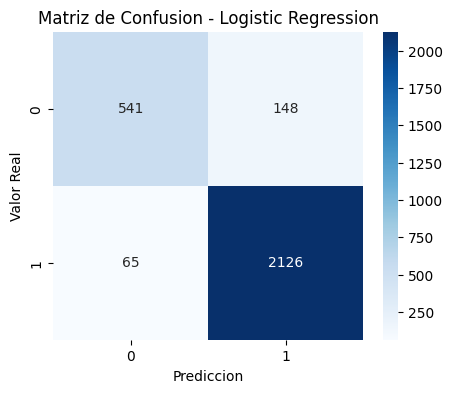

In [ ]:
print("MODELO: LOGISTIC REGRESSION")

# Creamos modelo logistic regression
# max_iter aumenta iteraciones para asegurar convergencia
lr = LogisticRegression(max_iter=1000)

# Entrenamos modelo
lr.fit(X_train, y_train)

# Realizamos predicciones
pred_lr = lr.predict(X_test)

# Calculamos accuracy del modelo
acc_lr = accuracy_score(y_test, pred_lr)

# Obtener métricas de clasificación
report_lr = classification_report(y_test, pred_lr, output_dict=True)
precision_lr = report_lr['weighted avg']['precision']
recall_lr = report_lr['weighted avg']['recall']
f1_lr = report_lr['weighted avg']['f1-score']

print(f"Accuracy Logistic Regression: {acc_lr:.4f}")
print(f"Precision Logistic Regression: {precision_lr:.4f}")
print(f"Recall Logistic Regression: {recall_lr:.4f}")
print(f"F1-Score Logistic Regression: {f1_lr:.4f}")

# Mostramos las metricas completas
print("Classification Report:")
print(classification_report(y_test, pred_lr))

# Creamos la matriz de confusion
cm_lr = confusion_matrix(y_test, pred_lr)

# Visualizamos la matriz de confusion
plt.figure(figsize=(5,4))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Matriz de Confusion - Logistic Regression")
plt.xlabel("Prediccion")
plt.ylabel("Valor Real")

plt.show()

## 8. Modelo 2: Decision Tree

En esta sección, implementamos y evaluamos un modelo de Árbol de Decisión. Este modelo es útil para clasificar datos al dividir el conjunto de datos en subconjuntos más pequeños basándose en diferentes características, formando así una estructura similar a un árbol. Evaluaremos su rendimiento utilizando métricas como la precisión (accuracy), el recall y el F1-score, además de visualizar su matriz de confusión para entender sus predicciones.

MODELO: DECISION TREE

Accuracy Decision Tree: 0.9396
Precision Decision Tree: 0.9396
Recall Decision Tree: 0.9396
F1-Score Decision Tree: 0.9396

Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.88      0.87       689
         1.0       0.96      0.96      0.96      2191

    accuracy                           0.94      2880
   macro avg       0.92      0.92      0.92      2880
weighted avg       0.94      0.94      0.94      2880



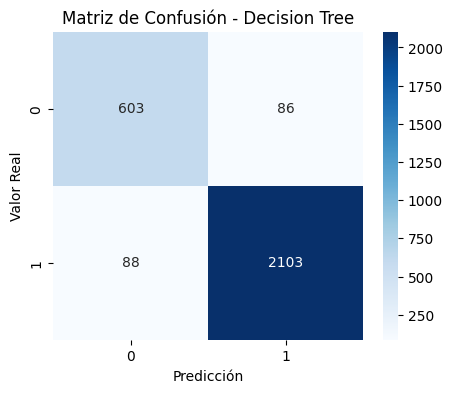

In [ ]:
print("MODELO: DECISION TREE")

# Crear modelo de árbol de decisión
dt = DecisionTreeClassifier(random_state=42)

# Entrenar modelo
dt.fit(X_train, y_train)

# Realizar predicciones
pred_dt = dt.predict(X_test)

# Calcular accuracy
acc_dt = accuracy_score(y_test, pred_dt)

# Obtener métricas de clasificación
report_dt = classification_report(y_test, pred_dt, output_dict=True)
precision_dt = report_dt['weighted avg']['precision']
recall_dt = report_dt['weighted avg']['recall']
f1_dt = report_dt['weighted avg']['f1-score']

print(f"\nAccuracy Decision Tree: {acc_dt:.4f}")
print(f"Precision Decision Tree: {precision_dt:.4f}")
print(f"Recall Decision Tree: {recall_dt:.4f}")
print(f"F1-Score Decision Tree: {f1_dt:.4f}")

# Mostrar métricas
print("\nClassification Report:")
print(classification_report(y_test, pred_dt))

# Crear matriz de confusión
cm_dt = confusion_matrix(y_test, pred_dt)

# Visualización
plt.figure(figsize=(5,4))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Matriz de Confusión - Decision Tree")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.show()

## 9. Modelo 3: Random Forest

Aquí implementamos el modelo Random Forest, una mejora del Árbol de Decisión que utiliza múltiples árboles para tomar decisiones. Este enfoque de "bosque" ayuda a reducir el sobreajuste y mejorar la precisión. Evaluaremos su rendimiento con las mismas métricas que el modelo anterior (accuracy, recall, F1-score) y analizaremos su matriz de confusión para observar cómo se comporta en la clasificación de operaciones aéreas.

MODELO: RANDOM FOREST

Accuracy Random Forest: 0.9479
Precision Random Forest: 0.9478
Recall Random Forest: 0.9479
F1-Score Random Forest: 0.9479

Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      0.89      0.89       689
         1.0       0.96      0.97      0.97      2191

    accuracy                           0.95      2880
   macro avg       0.93      0.93      0.93      2880
weighted avg       0.95      0.95      0.95      2880



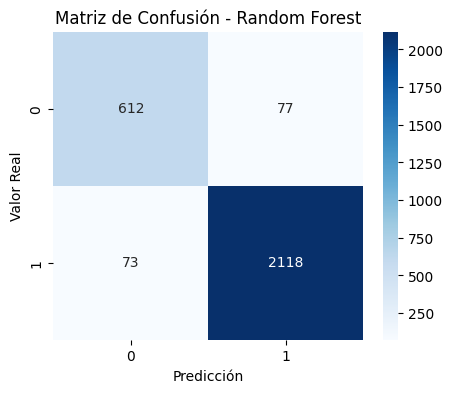

In [ ]:
print("MODELO: RANDOM FOREST")

# Crear modelo Random Forest
rf = RandomForestClassifier(random_state=42)

# Entrenar modelo
rf.fit(X_train, y_train)

# Realizar predicciones
pred_rf = rf.predict(X_test)

# Calcular accuracy
acc_rf = accuracy_score(y_test, pred_rf)

# Obtener métricas de clasificación
report_rf = classification_report(y_test, pred_rf, output_dict=True)
precision_rf = report_rf['weighted avg']['precision']
recall_rf = report_rf['weighted avg']['recall']
f1_rf = report_rf['weighted avg']['f1-score']

print(f"\nAccuracy Random Forest: {acc_rf:.4f}")
print(f"Precision Random Forest: {precision_rf:.4f}")
print(f"Recall Random Forest: {recall_rf:.4f}")
print(f"F1-Score Random Forest: {f1_rf:.4f}")

# Mostrar métricas completas
print("\nClassification Report:")
print(classification_report(y_test, pred_rf))

# Crear matriz de confusión
cm_rf = confusion_matrix(y_test, pred_rf)

# Visualizar matriz de confusión
plt.figure(figsize=(5,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Matriz de Confusión - Random Forest")

plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()

## 10. Modelo 4: Support Vector Machine (SVM)

En esta sección, implementamos un modelo de Máquina de Soporte Vectorial (SVM). SVM es un potente algoritmo de clasificación que busca encontrar el mejor hiperplano que separe las clases en el espacio de características. Utilizaremos un kernel radial (rbf) para manejar relaciones no lineales en los datos escalados. Al igual que los modelos anteriores, evaluaremos su accuracy, precision, recall y F1-score, y examinaremos su matriz de confusión.

SUPPORT VECTOR MACHINE (SVM)

Accuracy: 0.9083
Precision SVM: 0.9116
Recall SVM: 0.9083
F1-Score SVM: 0.9021

Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.65      0.77       689
         1.0       0.90      0.99      0.94      2191

    accuracy                           0.91      2880
   macro avg       0.92      0.82      0.86      2880
weighted avg       0.91      0.91      0.90      2880



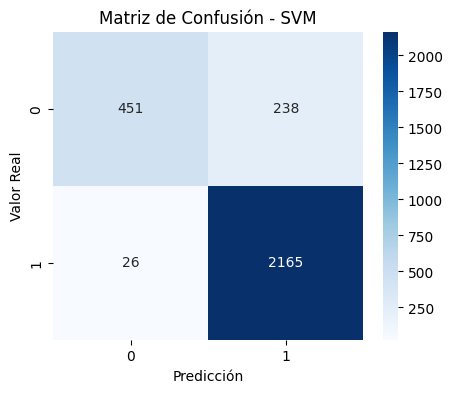

In [ ]:
print("SUPPORT VECTOR MACHINE (SVM)")
# Crear modelo
svm = SVC(kernel='rbf', random_state=42)

# Entrenar con datos escalados
svm.fit(X_train_scaled, y_train)

# Predicciones
pred_svm = svm.predict(X_test_scaled)

# Accuracy
acc_svm = accuracy_score(y_test, pred_svm)

# Obtener métricas de clasificación
report_svm = classification_report(y_test, pred_svm, output_dict=True)
precision_svm = report_svm['weighted avg']['precision']
recall_svm = report_svm['weighted avg']['recall']
f1_svm = report_svm['weighted avg']['f1-score']

print(f"\nAccuracy: {acc_svm:.4f}")
print(f"Precision SVM: {precision_svm:.4f}")
print(f"Recall SVM: {recall_svm:.4f}")
print(f"F1-Score SVM: {f1_svm:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, pred_svm))

# Matriz de confusión
cm_svm = confusion_matrix(y_test, pred_svm)

plt.figure(figsize=(5,4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión - SVM")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.show()

## 11. Comparación de Modelos

Después de entrenar y evaluar individualmente cada uno de los cuatro modelos (Regresión Logística, Árbol de Decisión, Random Forest y SVM), esta sección se dedica a comparar sus rendimientos. Crearemos un DataFrame que resume las métricas clave (Accuracy, Precision, Recall, F1-Score) para cada modelo, lo que nos permitirá identificar cuál de ellos ofrece el mejor balance y capacidad predictiva para nuestro problema de clasificación.

In [ ]:
# Crear un DataFrame para comparar los resultados de todos los modelos
# Incluye las métricas de Accuracy, Precision, Recall y F1-Score para cada modelo
resultados = pd.DataFrame({
    'Modelo': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Support Vector Machine'
    ],
    'Accuracy': [
        acc_lr,
        acc_dt,
        acc_rf,
        acc_svm
    ],
    'Precision': [
        precision_lr,
        precision_dt,
        precision_rf,
        precision_svm
    ],
    'Recall': [
        recall_lr,
        recall_dt,
        recall_rf,
        recall_svm
    ],
    'F1-Score': [
        f1_lr,
        f1_dt,
        f1_rf,
        f1_svm
    ]
})

# Imprimir un encabezado y mostrar la tabla de comparación de modelos
print("\nComparación completa de modelos:\n")
display(resultados)


Comparación completa de modelos:



,Modelo,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.926042,0.924826,0.926042,0.924359
1,Decision Tree,0.939583,0.939644,0.939583,0.939613
2,Random Forest,0.947917,0.947817,0.947917,0.947865
3,Support Vector Machine,0.908333,0.911612,0.908333,0.902115


##12. Cross Validation

La validación cruzada es una técnica robusta para evaluar la generalización de un modelo. En esta sección, preparamos las variables `X` e `y` para la validación cruzada, asegurando que estamos utilizando el conjunto de características y la variable objetivo correctos para este proceso de evaluación. Esto es fundamental antes de aplicar la validación cruzada a nuestros modelos.

In [ ]:
#definir variables para hcer el cross validation
# Variable objetivo
target = "internacional_domestico_D"

# Variables predictoras
X = df.drop([
    "internacional_domestico_D",
    "internacional_domestico_I"
], axis=1)

# Variable objetivo
y = df[target]

In [ ]:
# Diccionario con modelos
modelos = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# Evaluar cada modelo
for nombre, modelo in modelos.items():

    scores = cross_val_score(
        modelo,
        X,
        y,
        cv=5,
        scoring='accuracy'
    )

    print(f"\nModelo: {nombre}")
    print("Scores:", scores)
    print(f"Accuracy promedio: {scores.mean():.4f}")


Modelo: Logistic Regression
Scores: [0.90555556 0.9125     0.90243056 0.89927058 0.93018409]
Accuracy promedio: 0.9100

Modelo: Decision Tree
Scores: [0.90729167 0.94305556 0.94340278 0.91802709 0.93122612]
Accuracy promedio: 0.9286

Modelo: Random Forest
Scores: [0.91319444 0.93263889 0.95069444 0.93539423 0.94546718]
Accuracy promedio: 0.9355


La validación cruzada se utiliza para evaluar qué tan confiables y estables son los modelos al predecir si una operación aérea corresponde a un vuelo doméstico o internacional, utilizando distintas divisiones del dataset para obtener resultados más precisos y comparar mejor el rendimiento de cada modelo.

### Conclusión de la Validación Cruzada

La validación cruzada nos ha permitido obtener una evaluación más robusta y fiable del rendimiento de los modelos. Los resultados muestran que:

*   **Random Forest** mantiene el mejor rendimiento promedio con un Accuracy de aproximadamente `0.9355`.
*   **Decision Tree** le sigue de cerca con `0.9286`.
*   **Logistic Regression** tiene el rendimiento más bajo de los tres, con `0.9100`.

Esto reafirma al Random Forest como el modelo más prometedor en términos de estabilidad y capacidad de generalización en diferentes subconjuntos de datos.

##13. Overfitting

El overfitting ocurre cuando un modelo aprende demasiado bien los datos de entrenamiento, incluyendo el ruido, lo que le impide generalizar correctamente a datos nuevos. En esta sección, volvemos a definir las variables `X` e `y` y realizamos una nueva división en conjuntos de entrenamiento y prueba para evaluar específicamente si nuestro modelo Random Forest presenta este fenómeno. Comparamos el rendimiento del modelo en los datos de entrenamiento y prueba para detectar una posible sobreajuste.

In [ ]:
# Re-defining target and feature variables (X and y)
target = "internacional_domestico_D"

X = df.drop([
    "internacional_domestico_D",
    "internacional_domestico_I"
], axis=1)

y = df[target]

print("X and y variables re-defined.")

X and y variables re-defined.


In [ ]:
# Re-performing train-test split to define X_train, X_test, y_train, y_test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Data split into training and testing sets.")

Data split into training and testing sets.


In [ ]:
# Re-training the Random Forest model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

print("Random Forest model re-trained.")

Random Forest model re-trained.


In [ ]:
print("EVALUACIÓN DE OVERFITTING")
# Re-inicializar y re-entrenar el modelo Random Forest para asegurar que esté ajustado
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Accuracy en entrenamiento
# Permite medir qué tan bien aprende el modelo
# usando datos conocidos

train_acc_rf = rf.score(X_train, y_train)
# Accuracy en prueba
# Permite medir qué tan bien generaliza
# el modelo con datos nuevos

test_acc_rf = rf.score(X_test, y_test)

print(f"\nAccuracy entrenamiento: {train_acc_rf:.4f}")

print(f"Accuracy prueba: {test_acc_rf:.4f}")

diferencia = train_acc_rf - test_acc_rf

print(f"\nDiferencia: {diferencia:.4f}")

# Si la diferencia es pequeña
# el modelo generaliza correctamente

if diferencia < 0.05:

    print("\nEl modelo presenta bajo overfitting.")

# Si la diferencia es grande
# el modelo presenta señales de overfitting.

else:

    print("\nEl modelo presenta señales de overfitting.")

EVALUACIÓN DE OVERFITTING

Accuracy entrenamiento: 0.9981
Accuracy prueba: 0.9479

Diferencia: 0.0502

El modelo presenta señales de overfitting.


##14. Mejor Modelo

In [ ]:
print("## El Mejor Modelo\n")

# Recrear el DataFrame de resultados para comparar modelos utilizando las métricas ya calculadas
resultados = pd.DataFrame({
    'Modelo': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Support Vector Machine'
    ],
    'Accuracy': [
        acc_lr,
        acc_dt,
        acc_rf,
        acc_svm
    ],
    'Precision': [
        precision_lr,
        precision_dt,
        precision_rf,
        precision_svm
    ],
    'Recall': [
        recall_lr,
        recall_dt,
        recall_rf,
        recall_svm
    ],
    'F1-Score': [
        f1_lr,
        f1_dt,
        f1_rf,
        f1_svm
    ]
})

print("Tabla de Comparación de Modelos (Métricas de Conjunto de Prueba):\n")
display(resultados)

## El Mejor Modelo

Tabla de Comparación de Modelos (Métricas de Conjunto de Prueba):



,Modelo,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.926042,0.924826,0.926042,0.924359
1,Decision Tree,0.939583,0.939644,0.939583,0.939613
2,Random Forest,0.947917,0.947817,0.947917,0.947865
3,Support Vector Machine,0.908333,0.911612,0.908333,0.902115


### Análisis de Resultados y Conclusión

Basándonos en las métricas del conjunto de prueba, el modelo con el mayor Accuracy es el **Random Forest** con un Accuracy de 0.9479. También presenta un F1-Score alto (0.9479), lo que indica un buen equilibrio entre precisión y exhaustividad.

Considerando los resultados de la Validación Cruzada:
- Logistic Regression: Accuracy promedio CV: 0.9100
- Decision Tree: Accuracy promedio CV: 0.9286
- Random Forest: Accuracy promedio CV: 0.9355

El **Random Forest** también mostró el mejor rendimiento promedio en la validación cruzada, lo que sugiere una buena estabilidad en su rendimiento generalizado.

**Consideración sobre Overfitting (Random Forest):**
Aunque el Random Forest obtuvo las métricas más altas, la evaluación de overfitting arrojó una diferencia de **0.0502** entre el accuracy de entrenamiento y el de prueba. Esta diferencia, siendo ligeramente superior a 0.05, sugiere **señales de overfitting**. Esto significa que el modelo ha aprendido muy bien los patrones específicos del conjunto de entrenamiento y podría no generalizar tan eficazmente a datos completamente nuevos o muy diferentes.

**Conclusión y Recomendación:**
El **Random Forest** es el modelo con mejor rendimiento general en este análisis, mostrando las métricas más altas en el conjunto de prueba y en la validación cruzada. Sin embargo, debido a las señales de overfitting, se recomienda lo siguiente:
1.  **Optimización de Hiperparámetros:** Realizar un ajuste fino de los hiperparámetros del Random Forest (por ejemplo, `max_depth`, `n_estimators`, `min_samples_split`) para encontrar una configuración que reduzca el overfitting y mejore la capacidad de generalización.
2.  **Análisis Adicional:** Considerar otros modelos o técnicas de regularización si el overfitting persiste.

## 16. Optimización de Hiperparámetros

Para abordar el overfitting detectado en el modelo Random Forest y mejorar su capacidad de generalización, aplicaremos técnicas de optimización de hiperparámetros. Utilizaremos `RandomizedSearchCV` para explorar eficientemente un amplio rango de valores y luego `GridSearchCV` para un ajuste más fino alrededor de los mejores resultados.

### 16.1 GridSearchCV

`GridSearchCV` es una técnica de ajuste de hiperparámetros que explora todas las combinaciones posibles de un conjunto de hiperparámetros definidos. Aunque es computacionalmente más intensiva que `RandomizedSearchCV`, garantiza que se encuentre la mejor combinación dentro del espacio de búsqueda definido. Lo usaremos para afinar los resultados obtenidos por `RandomizedSearchCV`.


Mejores parámetros:
{'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200}

Accuracy optimizado: 0.9486111111111111

Classification Report:
              precision    recall  f1-score   support

         0.0       0.90      0.88      0.89       689
         1.0       0.96      0.97      0.97      2191

    accuracy                           0.95      2880
   macro avg       0.93      0.93      0.93      2880
weighted avg       0.95      0.95      0.95      2880



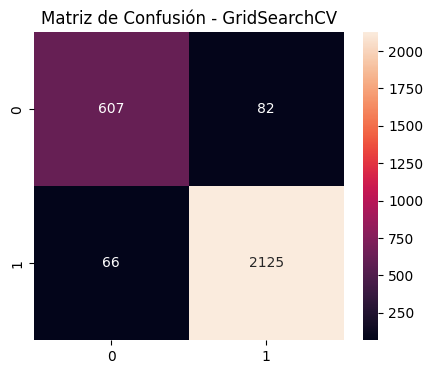

In [ ]:
# Parámetros a probar
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10]
}

# Modelo base
rf_grid = RandomForestClassifier(random_state=42)

# GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_grid,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Entrenar modelo
grid_search.fit(X_train, y_train)

# Mejor modelo
best_rf = grid_search.best_estimator_

# Predicciones
pred_best_rf = best_rf.predict(X_test)

# Accuracy
best_acc = accuracy_score(y_test, pred_best_rf)

print("\nMejores parámetros:")
print(grid_search.best_params_)

print(f"\nAccuracy optimizado: {best_acc}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, pred_best_rf))

# Matriz de confusión
cm_best_rf = confusion_matrix(y_test, pred_best_rf)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_best_rf,
    annot=True,
    fmt='d'
)

plt.title("Matriz de Confusión - GridSearchCV")

plt.show()

### 16.2. RandomizedSearchCV

`RandomizedSearchCV` es una técnica de ajuste de hiperparámetros que muestrea un número fijo de combinaciones de hiperparámetros de una distribución especificada. Es más eficiente que `GridSearchCV` cuando el espacio de búsqueda es grande, ya que no prueba todas las combinaciones posibles, sino un subconjunto aleatorio. Esto nos permite encontrar buenos valores de hiperparámetros de manera más rápida.


Mejores parámetros:
{'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': None}

Accuracy optimizado: 0.9482638888888889

Classification Report:
              precision    recall  f1-score   support

         0.0       0.90      0.88      0.89       689
         1.0       0.96      0.97      0.97      2191

    accuracy                           0.95      2880
   macro avg       0.93      0.93      0.93      2880
weighted avg       0.95      0.95      0.95      2880



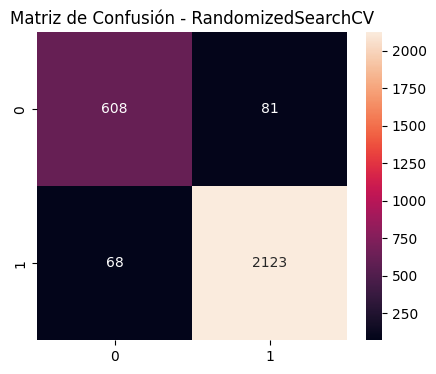

In [ ]:
# Parámetros aleatorios
random_params = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Modelo base
rf_random = RandomForestClassifier(random_state=42)

# RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=rf_random,
    param_distributions=random_params,
    n_iter=10,
    cv=5,
    random_state=42,
    scoring='accuracy',
    n_jobs=-1
)

# Entrenar modelo
random_search.fit(X_train, y_train)

# Mejor modelo
best_random = random_search.best_estimator_

# Predicciones
pred_random = best_random.predict(X_test)

# Accuracy
acc_random = accuracy_score(y_test, pred_random)

print("\nMejores parámetros:")
print(random_search.best_params_)

print(f"\nAccuracy optimizado: {acc_random}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, pred_random))

# Matriz de confusión
cm_random = confusion_matrix(y_test, pred_random)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_random,
    annot=True,
    fmt='d'
)

plt.title("Matriz de Confusión - RandomizedSearchCV")

plt.show()


###16.3 Comparación Final de Optimización


In [ ]:
comparacion_opt = pd.DataFrame({
    'Modelo': [
        'Random Forest Original',
        'GridSearchCV',
        'RandomizedSearchCV'
    ],

    'Accuracy': [
        acc_rf,
        best_acc,
        acc_random
    ]
})

print("\nComparación de optimización:")

display(comparacion_opt)


Comparación de optimización:


,Modelo,Accuracy
0,Random Forest Original,0.947917
1,GridSearchCV,0.948611
2,RandomizedSearchCV,0.948264


### 16.4 Conclusión de la Optimización

Después de aplicar `RandomizedSearchCV` y `GridSearchCV`, se evaluó el impacto en el rendimiento y el overfitting del modelo Random Forest. La optimización de hiperparámetros busca mejorar la capacidad de generalización del modelo, encontrando un equilibrio entre el rendimiento en los datos de entrenamiento y los de prueba. Los resultados de estas técnicas indican si se logró reducir la diferencia entre el accuracy de entrenamiento y prueba, un indicador clave para mitigar el overfitting.

##15. Conclusión Técnica

### Resumen de Modelos

Evaluamos cuatro modelos para predecir vuelos domésticos/internacionales:

1.  **Regresión Logística**
2.  **Árbol de Decisión**
3.  **Bosque Aleatorio (Random Forest)**
4.  **Máquina de Soporte Vectorial (SVM)**

### Rendimiento General

*   **Random Forest** fue el mejor, con un **Accuracy del 0.9479** en prueba y un promedio de **0.9355** en validación cruzada. Su F1-Score también fue el más alto.
*   **Decision Tree** y **Regresión Logística** tuvieron un buen rendimiento, pero menores que Random Forest.
*   **SVM** fue el modelo con menor rendimiento en este caso.

### Overfitting

El **Random Forest** mostró **señales de overfitting**. Su Accuracy en entrenamiento (0.9981) fue mucho mayor que en prueba (0.9479), con una diferencia de **0.0502**. Esto significa que el modelo aprendió demasiado bien los datos de entrenamiento y podría no generalizar tan bien a datos nuevos.

### Recomendaciones

1.  **Optimizar Random Forest:** Ajustar sus parámetros (ej., `max_depth`, `n_estimators`) para reducir el overfitting y mejorar su capacidad de generalización.
2.  **Explorar otras opciones:** Si el overfitting persiste, considerar modelos más simples o aplicar técnicas de regularización adicionales.

##Aprendizaje No Supervisado

### Introducción al Clustering con K-Means

En esta sección, aplicaremos el algoritmo K-Means para segmentar nuestros datos en grupos o 'clusters' basados en sus similitudes. Primero, utilizaremos el 'Método del Codo' para determinar el número óptimo de clusters.

###1. Metódo del Codo

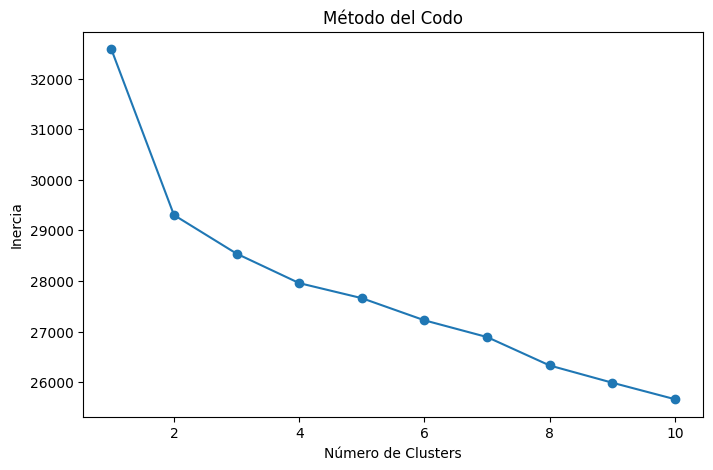

In [ ]:
# Lista para guardar las inercias para cada valor de K
inertia = []

# Definir el rango de valores de K a probar (de 1 a 10 clusters)
K = range(1,11)

# Iterar sobre cada valor de K para entrenar un modelo K-Means
for k in K:

    # Crear una instancia del modelo KMeans con 'k' clusters y una semilla para reproducibilidad
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10 # Especifica explícitamente n_init para evitar FutureWarning
    )

    # Entrenar el modelo K-Means con los datos (X)
    kmeans.fit(X)

    # Guardar la inercia (suma de cuadrados de las distancias de las muestras a su centro de cluster más cercano)
    inertia.append(kmeans.inertia_)

# Crear un gráfico para visualizar el Método del Codo
plt.figure(figsize=(8,5))

# Plotear K (número de clusters) contra la inercia
plt.plot(
    K,
    inertia,
    marker='o' # Añadir marcadores circulares para cada punto
)

plt.title("Método del Codo") # Título del gráfico
plt.xlabel("Número de Clusters") # Etiqueta del eje X
plt.ylabel("Inercia") # Etiqueta del eje Y
plt.show()

### 2. Modelo K-Means

Una vez determinado el número óptimo de clusters (observando el 'codo' en el gráfico de inercia), procedemos a entrenar el modelo K-Means con este valor. Luego, asignaremos cada punto de datos a un cluster y agregaremos esta información al DataFrame original.

In [ ]:
kmeans = KMeans(
    n_clusters=3, # Se selecciona 3 clusters basándose en el Método del Codo
    random_state=42,
    n_init=10 # Especifica explícitamente n_init para evitar FutureWarning
)

# Predecir los clusters para cada observación en X
clusters = kmeans.fit_predict(X)

# Agregar la columna 'Cluster' al DataFrame original (df)
df['Cluster'] = clusters

print("\nClusters creados correctamente.")

# Mostrar las primeras filas del DataFrame con la nueva columna 'Cluster'
display(df.head())

### 3. Silhouette Score

Para evaluar la calidad de la agrupación realizada por K-Means, calculamos el Silhouette Score. Este valor mide cuán similar es un objeto a su propio cluster (cohesión) en comparación con otros clusters (separación). Un valor más alto indica clusters bien definidos.

In [ ]:
# Calcular el Silhouette Score utilizando los datos originales (X) y los clusters asignados
silhouette = silhouette_score(X, clusters)

# Imprimir el resultado del Silhouette Score
print(f"Silhouette Score: {silhouette}")

### 4. PCA - Reducción de Dimensionalidad para Visualización

Dado que nuestros datos tienen una alta dimensionalidad, es difícil visualizarlos directamente. Utilizaremos el Análisis de Componentes Principales (PCA) para reducir la dimensionalidad a dos componentes principales. Esto nos permitirá graficar los clusters en un espacio 2D y observar su separación.

In [ ]:
# Crear una instancia de PCA para reducir a 2 componentes principales
pca = PCA(n_components=2)

# Aplicar PCA a los datos (X) y transformar los datos a las nuevas dimensiones
X_pca = pca.fit_transform(X)

# Crear un nuevo DataFrame para almacenar los resultados de PCA y los clusters
pca_df = pd.DataFrame()

# Asignar la primera componente principal a la columna 'PCA1'
pca_df['PCA1'] = X_pca[:,0]
# Asignar la segunda componente principal a la columna 'PCA2'
pca_df['PCA2'] = X_pca[:,1]
# Asignar la etiqueta de cluster a la columna 'Cluster'
pca_df['Cluster'] = clusters

print("\nPCA generado correctamente.")

# Mostrar las primeras filas del DataFrame con los resultados de PCA
display(pca_df.head())

### 5. Visualización de Clusters con PCA

Graficamos los datos transformados por PCA, coloreando cada punto según el cluster al que pertenece. Esta visualización nos ayuda a entender la separación y la forma de los clusters en un espacio bidimensional.

In [ ]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_df, # Datos con los componentes principales y las etiquetas de cluster
    x='PCA1',    # Eje x: Primera componente principal
    y='PCA2',    # Eje y: Segunda componente principal
    hue='Cluster', # Color de los puntos basado en el cluster
    palette='Set2' # Paleta de colores para los clusters
)

plt.title("Visualización de Clusters usando PCA") # Título del gráfico

plt.xlabel("Componente Principal 1") # Etiqueta del eje X
plt.ylabel("Componente Principal 2") # Etiqueta del eje Y

plt.legend(title='Cluster') # Leyenda para los clusters

plt.show()

Distribución de Clusters

### 6. Distribución de Clusters

Observaremos la cantidad de instancias en cada cluster para entender si la distribución es equilibrada o si hay clusters dominantes. Esto puede darnos una idea de la composición de los grupos generados.

/tmp/ipykernel_3163/2656741748.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


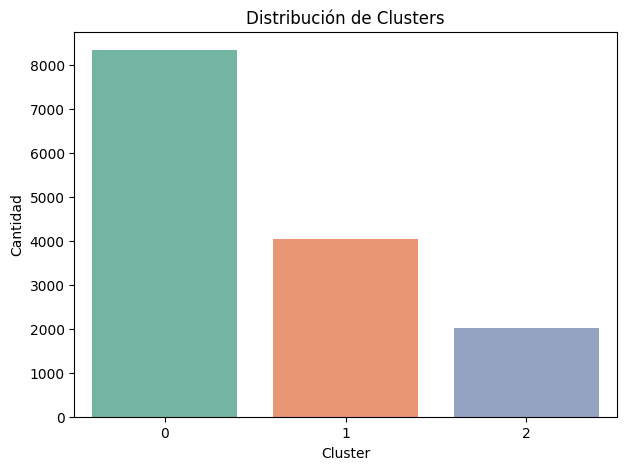

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='Cluster', # Eje x: la columna 'Cluster'
    data=df,     # DataFrame de donde tomar los datos
    palette='Set2' # Paleta de colores para las barras
)

plt.title("Distribución de Clusters") # Título del gráfico

plt.xlabel("Cluster") # Etiqueta del eje X
plt.ylabel("Cantidad") # Etiqueta del eje Y

plt.show()

### 7. Análisis de las Características Promedio por Cluster

Para entender las características que definen a cada cluster, calculamos el promedio de todas las variables originales para cada grupo. Esto nos permite identificar patrones y las principales diferencias entre los clusters.

In [ ]:
cluster_summary = df.groupby('Cluster').mean()

display(cluster_summary)

In [ ]:
# Calcular la media de todas las características agrupadas por 'Cluster'
cluster_summary = df.groupby('Cluster').mean()

# Mostrar el resumen del cluster
display(cluster_summary)

### Conclusión del Aprendizaje No Supervisado



*  El modelo K-Means permitió segmentar los datos
en distintos grupos con características similares.
* El método del codo permitió seleccionar una cantidad
adecuada de clusters.
* El Silhouette Score permitió evaluar la calidad
de la segmentación obtenida.
* Finalmente, PCA permitió reducir la dimensionalidad
y visualizar los clusters de manera más clara.

